✅ Nightly Data Synced: 8 days recorded.

📊 DAILY VOLATILITY REPORT
--------------------------------------------------
StubHub     : 📉  -2.89% ($-66.00)
SeatGeek    : 📉    nan% ($+nan)
VividSeats  : 📉    nan% ($+nan)
Ticketmaster: 📉    nan% ($+nan)
--------------------------------------------------


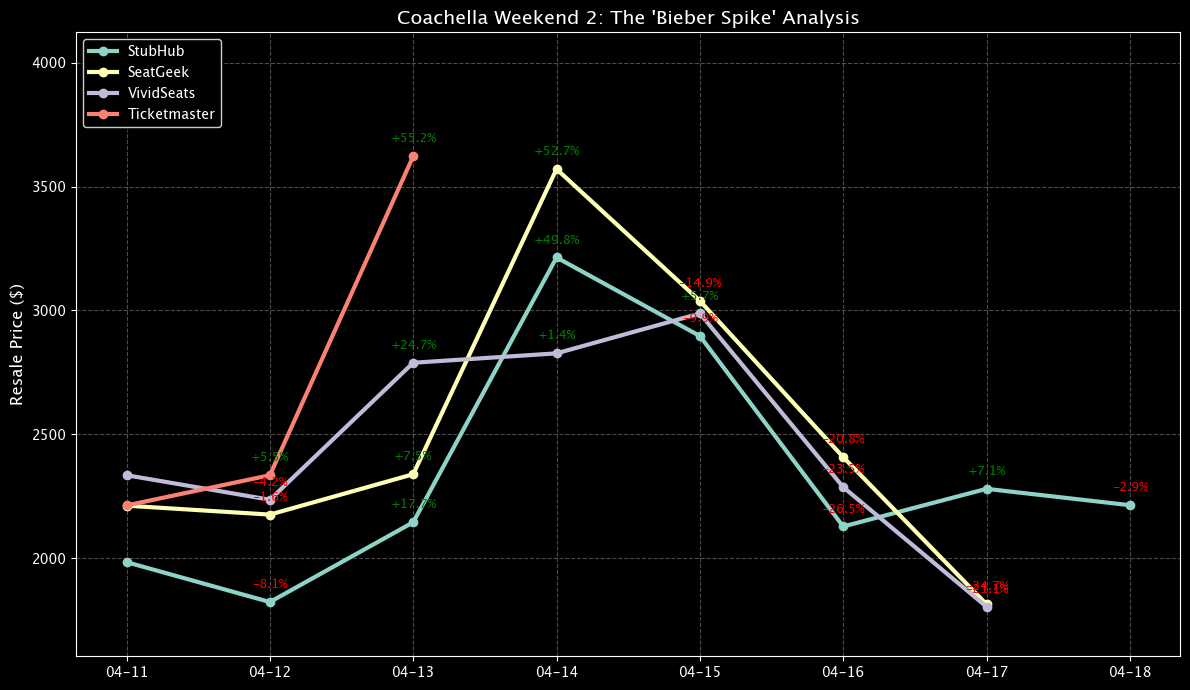

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ======================================================
# DAILY TRACKER: Run this nightly (9:00 PM - 11:00 PM)
# ======================================================

# KEY: [ "Date", StubHub, SeatGeek, VividSeats, Ticketmaster ]
price_history = [
    ["2026-04-11", 1984, 2212, 2335, 2213], # Saturday Baseline
    ["2026-04-12", 1823, 2176, 2236, 2335], # Sunday Night
    ["2026-04-13", 2145, 2339, 2789, 3623], # Monday:
    ["2026-04-14", 3214,    3571,    2827,    None],    # Tuesday
    ["2026-04-15", 2897,    3039,    2988,    None],    # Wednesday
    ["2026-04-16", 2128,    2408,    2287,    None],    # Thursday
    ["2026-04-17", 2280,    1814,    1804,    None],    # Friday (Weekend 2 Starts)
    ["2026-04-18", 2214,    None,    None,    None],    # Saturday (Day of)
]
# ======================================================

FILENAME = "weekend_2_prices_3_day_pass.csv"

def process_and_plot():
    columns = ["Date", "StubHub", "SeatGeek", "VividSeats", "Ticketmaster"]
    platforms = ["StubHub", "SeatGeek", "VividSeats", "Ticketmaster"]

    valid_data = [row for row in price_history if row[1] is not None and row[1] > 0]
    df = pd.DataFrame(valid_data, columns=columns)
    df['Date'] = pd.to_datetime(df['Date'])

    df.to_csv(FILENAME, index=False)
    print(f"✅ Nightly Data Synced: {len(valid_data)} days recorded.\n")

    if len(df) < 2:
        print("📍 Baseline set! Annotations will appear after tomorrow's nightly run.")
        return

    # terminal report
    print("📊 DAILY VOLATILITY REPORT")
    print("-" * 50)
    current_day = df.iloc[-1]
    previous_day = df.iloc[-2]
    for platform in platforms:
        diff = current_day[platform] - previous_day[platform]
        pct = (diff / previous_day[platform]) * 100
        direction = "📈" if diff > 0 else "📉"
        print(f"{platform:<12}: {direction} {pct:>6.2f}% (${diff:+.2f})")
    print("-" * 50)

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 7))

    for platform in platforms:
        # Plot the line
        line, = ax.plot(df['Date'], df[platform], marker='o', linewidth=3, label=platform)

        # --- NEW: Annotation Logic ---
        for i in range(1, len(df)):
            curr_val = df.iloc[i][platform]
            prev_val = df.iloc[i-1][platform]
            pct_change = ((curr_val - prev_val) / prev_val) * 100

            # Determine text color and sign
            color = 'green' if pct_change > 0 else 'red'
            label_text = f"{pct_change:+.1f}%"

            # Place the note slightly above the point
            ax.annotate(label_text,
                        xy=(df.iloc[i]['Date'], curr_val),
                        xytext=(0, 10), # 10 points vertical offset
                        textcoords='offset points',
                        ha='center',
                        fontsize=9,
                        fontweight='bold',
                        color=color)

    # Styling
    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

    plt.title("Coachella Weekend 2: The 'Bieber Spike' Analysis", fontsize=14, fontweight='bold')
    plt.ylabel("Resale Price ($)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=True, loc='upper left', shadow=True)

    # Pad the top so labels don't hit the ceiling
    plt.ylim(df[platforms].min().min() - 200, df[platforms].max().max() + 500)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    process_and_plot()

✅ Data Synced: 6 full days recorded.


📊 HISTORICAL VOLATILITY REPORT (% Change)
-----------------------------------------------------------------
Date     |    StubHub |   SeatGeek |      Vivid |    T-Master
-----------------------------------------------------------------
04-12    |      -8.1% |      -1.6% |      -4.2% |       5.5%
04-13    |      17.7% |       7.5% |      24.7% |      55.2%
04-14    |      49.8% |      52.7% |       1.4% |   SOLD OUT
04-15    |      -9.9% |     -14.9% |       5.7% |   SOLD OUT
04-16    |     -26.5% |     -20.8% |     -23.5% |   SOLD OUT
-----------------------------------------------------------------


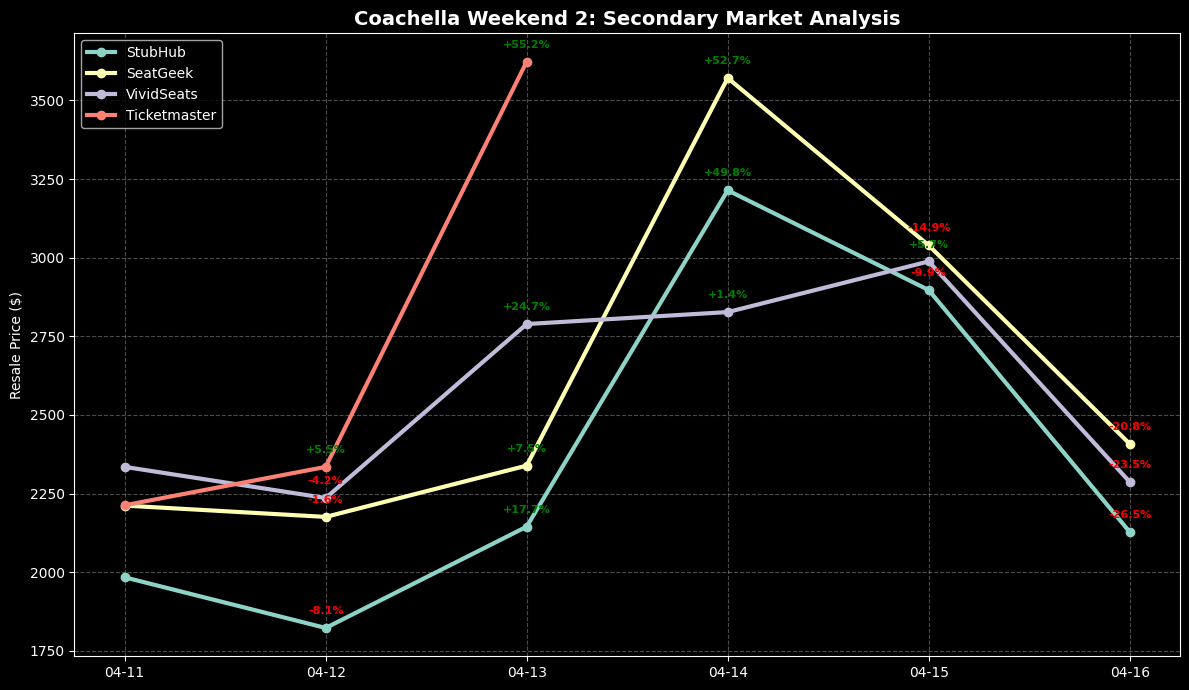

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# ======================================================
# DAILY TRACKER: Nightly Closing Prices
# ======================================================

price_history = [
    ["2026-04-11", 1984, 2212, 2335, 2213],
    ["2026-04-12", 1823, 2176, 2236, 2335],
    ["2026-04-13", 2145, 2339, 2789, 3623],
    ["2026-04-14", 3214, 3571, 2827, None],
    ["2026-04-15", 2897, 3039, 2988, None],
    ["2026-04-16", 2128, 2408, 2287, None],
    ["2026-04-17", 0,    0,    0,    0],    # <--- Waiting for your nightly pull!
]
# ======================================================

FILENAME = "coachella_market_history.csv"

def process_and_plot():
    columns = ["Date", "StubHub", "SeatGeek", "VividSeats", "Ticketmaster"]
    platforms = ["StubHub", "SeatGeek", "VividSeats", "Ticketmaster"]

    # Filter for valid rows (where the first platform has a price > 0)
    # This keeps today's '0' row out of the chart until you update it.
    df_all = pd.DataFrame(price_history, columns=columns)
    df_all['Date'] = pd.to_datetime(df_all['Date'])

    df_valid = df_all[df_all['StubHub'] > 0].copy()

    print(f"✅ Data Synced: {len(df_valid)} full days recorded.\n")

# --- Full Historical Volatility Table ---
    print("\n📊 HISTORICAL VOLATILITY REPORT (% Change)")
    print("-" * 65)
    # Using consistent widths: Date(8), Columns(12 each)
    header = f"{'Date':<8} | {'StubHub':>10} | {'SeatGeek':>10} | {'Vivid':>10} | {'T-Master':>11}"
    print(header)
    print("-" * 65)

    pct_df = df_valid[platforms].pct_change() * 100

    for i in range(1, len(df_valid)):
        date_str = df_valid.iloc[i]['Date'].strftime('%m-%d')
        row_str = f"{date_str:<8}"

        for platform in platforms:
            val = pct_df.iloc[i][platform]
            # Check if the current value is None (Sold Out)
            if pd.isna(df_valid.iloc[i][platform]):
                row_str += f" | {'SOLD OUT':>10}"
            # Check if current is valid but previous was None (Can't calc % yet)
            elif pd.isna(val):
                row_str += f" | {'---':>10}"
            else:
                row_str += f" | {val:>9.1f}%"
        print(row_str)
    print("-" * 65)

    # Visualization
    fig, ax = plt.subplots(figsize=(12, 7))
    for platform in platforms:
        plot_df = df_valid[['Date', platform]].dropna()
        ax.plot(plot_df['Date'], plot_df[platform], marker='o', linewidth=3, label=platform)

        for i in range(1, len(df_valid)):
            curr_val = df_valid.iloc[i][platform]
            prev_val = df_valid.iloc[i-1][platform]
            if pd.notna(curr_val) and pd.notna(prev_val):
                pct_change = ((curr_val - prev_val) / prev_val) * 100
                color = 'green' if pct_change > 0 else 'red'
                ax.annotate(f"{pct_change:+.1f}%", xy=(df_valid.iloc[i]['Date'], curr_val),
                            xytext=(0, 10), textcoords='offset points', ha='center',
                            fontsize=8, fontweight='bold', color=color)

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    plt.title("Coachella Weekend 2: Secondary Market Analysis", fontsize=14, fontweight='bold')
    plt.ylabel("Resale Price ($)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=True, loc='upper left')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    process_and_plot()